In [3]:
import xarray as xr
import numpy as np
import os

def _load_sample(data_dir, index = 1):
    data_dir = os.path.normpath(data_dir)
    sub_dir = os.path.join(data_dir, "train")

    files = [os.path.join(sub_dir, f) for f in sorted(os.listdir(sub_dir)) if f.endswith(".nc")]
    
    file_path = files[index]

    # Load the .nc file.
    dataset = xr.load_dataset(file_path)
    
    return  dataset

filepath = 'C:/Users/perrydebussy/Project/Study/masterarbeit/data'
file = _load_sample(filepath)


In [ ]:
file.to_array()

variables = ['TMQ', 'U850', 'V850', 'UBOT', 'VBOT', 'QREFHT', 'PS', 'PSL', 
                        'T200', 'T500', 'PRECT', 'TS', 'TREFHT', 'Z1000', 'Z200', 'ZBOT']

imgs = []
for var in variables:
    var = file.to_array().sel(variable=var).values
    var = np.squeeze(var)
    imgs.append(var)
       


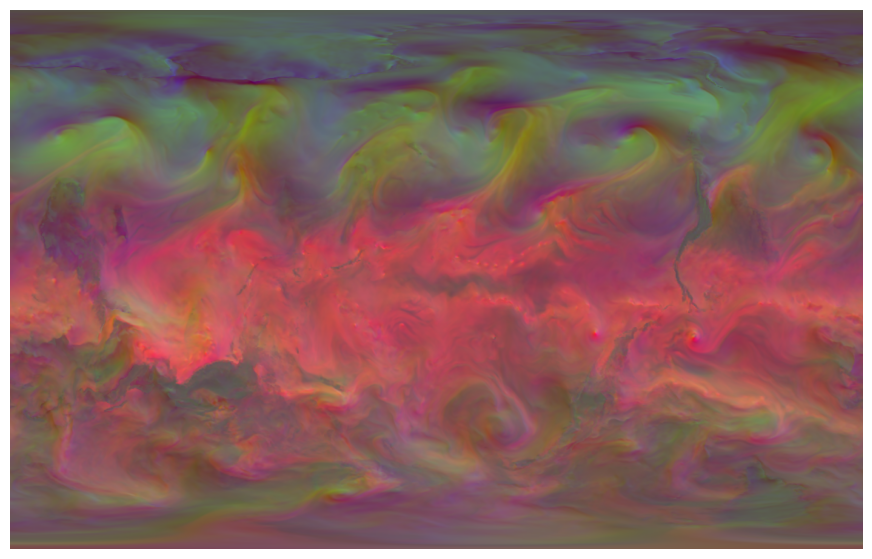

In [23]:
rgb_image = np.stack([imgs[0], imgs[1], imgs[2]], axis=-1)
rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())
rgb_image = (rgb_image * 255).astype(np.uint8)

import matplotlib.pyplot as plt

plt.figure(frameon=False, figsize=(11, 7))
plt.imshow(rgb_image, aspect='auto')
plt.gca().set_axis_off()
plt.margins(0,0)


In [ ]:
for img in imgs:
        import matplotlib.pyplot as plt

        plt.figure(frameon=False, figsize=(11, 7))
        plt.imshow(img, aspect='auto')
        plt.gca().set_axis_off()
        plt.margins(0,0)
        plt.set_cmap('gray')
        
        
        plt.show()